# PHÁT HIỆN BẤT THƯỜNG TRÊN DỮ LIỆU CẢM BIẾN TÀU CON THOI NASA (STATLOG SHUTTLE)
## MÔ HÌNH HỌC MÁY KHÔNG GIÁM SÁT ISOLATION FOREST (TRIỂN KHAI THUẦN NUMPY)

> **Phương pháp luận nghiên cứu**: Báo cáo được cấu trúc và triển khai tuần tự theo 21 bước chuẩn hóa trong quy trình phát triển mô hình Machine Learning:
> `Problem Definition → Nature of ML Problem → Domain Understanding → Data Cleaning → Feature Scaling → Categorical Encoding → Algorithm Selection → Feature Engineering → Data Splitting → Splitting Strategy → Baseline Model → No Free Lunch Analysis → Bias-Variance Tradeoff → Hyperparameter Tuning → Evaluation Metrics → Cross-Validation → Model Training → Statistical Testing → Error Analysis → Interpretability & RCA → Deployment Pipeline`


## BƯỚC 1: XÁC ĐỊNH BÀI TOÁN (PROBLEM DEFINITION)

- **Mục tiêu kỹ thuật**: Nhận diện sớm các sai lệch trạng thái vận hành vật lý (biến thiên áp suất thủy lực, xung nhiệt độ buồng trao đổi, dao động chu kỳ bơm) từ hệ thống telemetry tàu con thoi NASA.
- **Không gian đầu vào ($\mathbf{X}$)**: Ma trận dữ liệu quan trắc thô $\mathbf{X} \in \mathbb{R}^{58,000 \times 10}$ gồm 10 biến định lượng liên tục và rời rạc (`feat_1` đến `feat_10`).
- **Không gian đầu ra ($\hat{Y}$)**:
  1. Điểm chỉ số dị biệt chuẩn hóa $s(\mathbf{x}) \in [0, 1]$ biểu diễn mức độ cô lập không gian của mẫu quan sát.
  2. Quyết định gán nhãn suy diễn nhị phân $\hat{y} \in \{0, 1\}$ dựa trên các ngưỡng quyết định phân vị và lý thuyết.
- **Phân loại bài toán**: Phát hiện bất thường thuần không giám sát (Unsupervised Anomaly Detection). Tập dữ liệu không chứa nhãn phân lớp mục tiêu ($y$) trong toàn bộ chu trình xây dựng mô hình.


## BƯỚC 2: XÁC ĐỊNH BẢN CHẤT CỦA BÀI TOÁN MACHINE LEARNING

- **Luận chứng kỹ thuật giữa Học máy và Hệ luật chuyên gia (Rule-based Systems)**:
  - Hệ thống tàu con thoi có tương quan đa biến phi tuyến phức tạp giữa 10 kênh đo đạc vật lý. Phương pháp tiếp cận dựa trên hệ luật cố định (hard-coded rules / if-else) không thể bao quát các trạng thái lỗi kết hợp chưa từng ghi nhận trong tiền lệ.
  - Dị thường trong dữ liệu cảm biến hàng không vũ trụ là các sự kiện hiếm (rare events) và có độ phân tán cao trong không gian đa chiều $\mathbb{R}^{10}$.
- **Mô hình học máy phù hợp (Learning Paradigm)**:
  - **Học không giám sát (Unsupervised Learning)**: Mô hình tự động khai phá cấu trúc mật độ và phân hoạch hình học của không gian quan sát mà không phụ thuộc vào biến mục tiêu định trước.


## BƯỚC 3: KHẢO SÁT LĨNH VỰC VÀ KHÔNG GIAN DỮ LIỆU (DOMAIN & DATA UNDERSTANDING)

- **Đặc tả miền ứng dụng (Domain Specification)**: Tập dữ liệu telemetry NASA Shuttle Statlog ghi nhận chuỗi đo lường liên tục từ hệ thống van điều tiết tản nhiệt (Radiator valve) và chu trình điều áp động cơ tàu con thoi.
- **Ý nghĩa kỹ thuật của 10 kênh cảm biến**:
  - `feat_1` - `feat_5`: Áp suất vận hành và độ mở hành trình của hệ thống van thủy lực điều tiết.
  - `feat_6` - `feat_8`: Thông số lưu lượng chất tải nhiệt và nhiệt độ buồng trao đổi nhiệt.
  - `feat_9` - `feat_10`: Tín hiệu điện áp điều khiển và biến đếm chu kỳ xung bơm áp lực.
- **Phương pháp phân tích**: Đánh giá phân phối hình thái dữ liệu qua các chỉ số thống kê bậc 1 đến bậc 4 (Mean, Standard Deviation, Skewness, Kurtosis) và ma trận hiệp phương sai tương quan Pearson.


In [19]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập hiển thị chuẩn mực khoa học
pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 1000)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

# Thêm thư mục gốc vào PYTHONPATH
sys.path.append(os.path.abspath('..'))
from model import IsolationForest
from run_pipeline import (
    train_test_split,
    KFold,
    unsupervised_feature_importance,
    explain_anomalies_root_cause
)

# Nạp dữ liệu cảm biến thô
data_path = 'shuttle.csv'
feature_cols = [f'feat_{i}' for i in range(1, 11)]
df_raw = pd.read_csv(data_path, header=None, names=feature_cols)
X_raw = df_raw.copy()

print("==================================================")
print("MÔI TRƯỜNG VÀ DỮ LIỆU CẢM BIẾN TELEMETRY NASA SHUTTLE")
print("==================================================")
print(f"Kích thước ma trận thô: {X_raw.shape[0]:,} dòng x {X_raw.shape[1]} cột")
print(f"Danh sách các thuộc tính: {list(X_raw.columns)}")


MÔI TRƯỜNG VÀ DỮ LIỆU CẢM BIẾN TELEMETRY NASA SHUTTLE
Kích thước ma trận thô: 58,000 dòng x 10 cột
Danh sách các thuộc tính: ['feat_1', 'feat_2', 'feat_3', 'feat_4', 'feat_5', 'feat_6', 'feat_7', 'feat_8', 'feat_9', 'feat_10']


In [20]:
# Bảng thống kê mô tả chi tiết không gian 10 đặc trưng cảm biến
stats_df = pd.DataFrame({
    'Kiểu dữ liệu': X_raw.dtypes,
    'Kỳ vọng (Mean)': X_raw.mean(),
    'Độ lệch chuẩn (Std)': X_raw.std(),
    'Cực tiểu (Min)': X_raw.min(),
    'Trung vị (Median)': X_raw.median(),
    'Cực đại (Max)': X_raw.max(),
    'Độ lệch (Skewness)': X_raw.skew(),
    'Độ nhọn (Kurtosis)': X_raw.kurtosis()
})

print("=== BẢNG THỐNG KÊ MÔ TẢ HÌNH THÁI DỮ LIỆU (10 CẢM BIẾN) ===")
print(stats_df.round(3).to_string())


=== BẢNG THỐNG KÊ MÔ TẢ HÌNH THÁI DỮ LIỆU (10 CẢM BIẾN) ===
        Kiểu dữ liệu  Kỳ vọng (Mean)  Độ lệch chuẩn (Std)  Cực tiểu (Min)  Trung vị (Median)  Cực đại (Max)  Độ lệch (Skewness)  Độ nhọn (Kurtosis)
feat_1         int64          48.238               12.238              27               45.0            126               2.181               6.509
feat_2         int64          -0.019               77.958           -4821                0.0           5075               6.438            2647.317
feat_3         int64          85.349                8.903              21               83.0            149               1.096               0.544
feat_4         int64           0.260               36.522           -3939                0.0           3830              31.688            7698.225
feat_5         int64          34.550               21.660            -188               42.0            436              -1.162               8.547
feat_6         int64           1.608              21

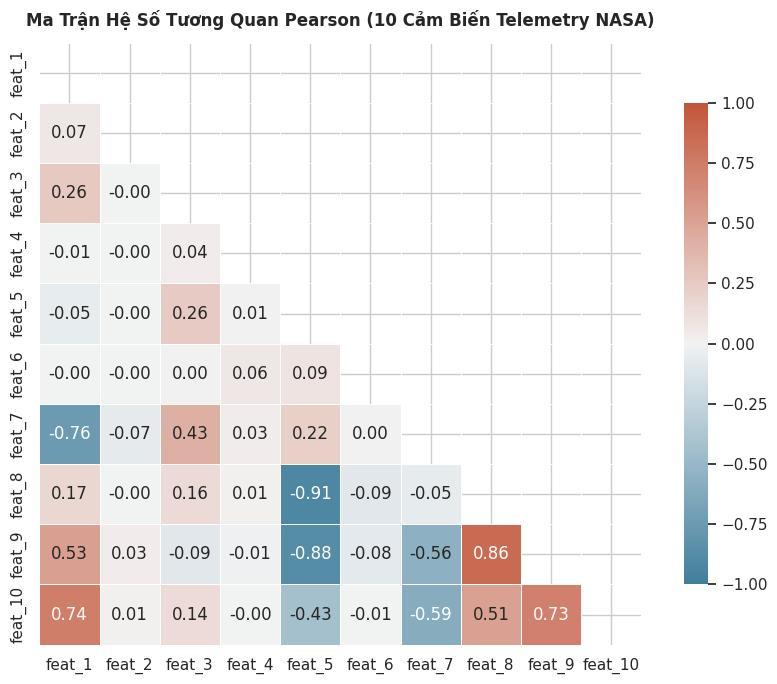

In [21]:
# Ma trận tương quan Pearson giữa 10 đặc trưng cảm biến
plt.figure(figsize=(9, 7), dpi=100)
corr_matrix = X_raw.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    corr_matrix, 
    mask=mask, 
    cmap=cmap, 
    vmax=1.0, 
    vmin=-1.0, 
    center=0,
    annot=True, 
    fmt='.2f', 
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .8}
)
plt.title('Ma Trận Hệ Số Tương Quan Pearson (10 Cảm Biến Telemetry NASA)', fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


## BƯỚC 4: KHÁM PHÁ VÀ XỬ LÝ DỮ LIỆU (DATA EXPLORATION & CLEANING)

- **Đánh giá tính toàn vẹn dữ liệu**: Kiểm tra các mẫu khuyết thiếu (Missing Values / NaN) và các giá trị vô hạn (Inf) trên toàn bộ 58,000 quan sát.
- **Đặc tính bản ghi trùng lặp**: Các bản ghi đồng nhất biểu thị trạng thái vận hành tĩnh ổn định của cảm biến trong chu kỳ trích mẫu tốc độ cao, do đó được giữ nguyên để duy trì chính xác tỷ lệ phân bố mật độ tự nhiên.
- **Nguyên lý bảo toàn giá trị ngoại lai (Outlier Retention Principle)**:
  - Trong bài toán phát hiện dị thường, các giá trị ngoại lai đa chiều phản ánh trực tiếp trạng thái bất thường của thiết bị phần cứng.
  - Việc áp dụng các kỹ thuật lọc hoặc loại bỏ ngoại lai truyền thống (như Winsorization hay Z-score truncation) sẽ làm triệt tiêu các mẫu dị biệt cần phát hiện, phá vỡ tính khách quan của dữ liệu quan trắc.


KIỂM TRA TÍNH TOÀN VẸN CỦA DỮ LIỆU TELEMETRY
Tổng số giá trị khuyết thiếu (NaN): 0
Tổng số giá trị vô hạn (Inf): 0
Số lượng bản ghi trùng trạng thái cảm biến: 0 (0.00%)
Trạng thái dữ liệu: HOÀN TOÀN HỢP LỆ VÀ SẠCH


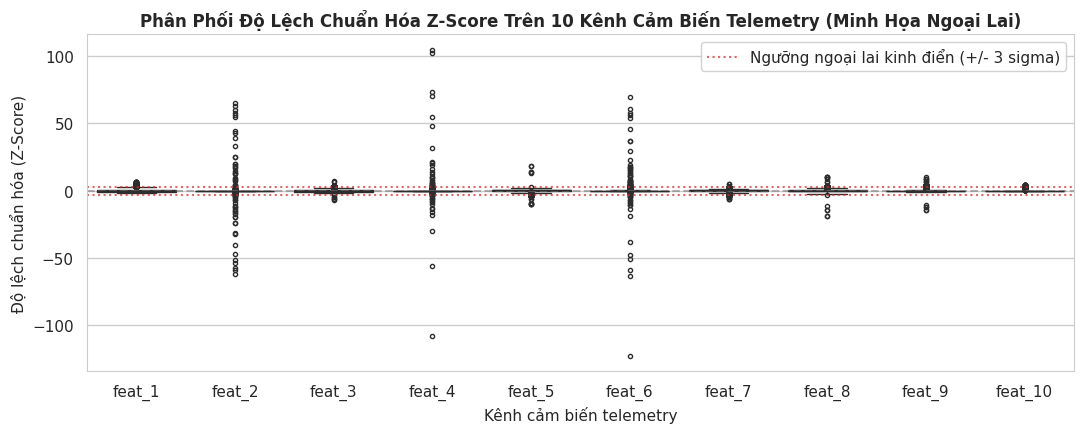

In [22]:
# Kiểm tra tính toàn vẹn dữ liệu
n_missing = int(X_raw.isnull().sum().sum())
n_inf = int(np.isinf(X_raw.to_numpy()).sum())
n_duplicates = int(X_raw.duplicated().sum())

print("==================================================")
print("KIỂM TRA TÍNH TOÀN VẸN CỦA DỮ LIỆU TELEMETRY")
print("==================================================")
print(f"Tổng số giá trị khuyết thiếu (NaN): {n_missing}")
print(f"Tổng số giá trị vô hạn (Inf): {n_inf}")
print(f"Số lượng bản ghi trùng trạng thái cảm biến: {n_duplicates:,} ({n_duplicates/len(X_raw)*100:.2f}%)")
print(f"Trạng thái dữ liệu: {'HOÀN TOÀN HỢP LỆ VÀ SẠCH' if n_missing == 0 and n_inf == 0 else 'CẦN XỬ LÝ'}")

# Trực quan hóa phân phối ngoại lai trên 10 kênh cảm biến telemetry (Z-score Boxplots)
Z_scores = (X_raw - X_raw.mean()) / X_raw.std()
plt.figure(figsize=(11, 4.5), dpi=100)
sns.boxplot(data=Z_scores, palette="Blues_r", fliersize=3, linewidth=1)
plt.axhline(0, color='gray', linestyle='--', alpha=0.6)
plt.axhline(3, color='#d62728', linestyle=':', alpha=0.7, label='Ngưỡng ngoại lai kinh điển (+/- 3 sigma)')
plt.axhline(-3, color='#d62728', linestyle=':', alpha=0.7)
plt.title('Phân Phối Độ Lệch Chuẩn Hóa Z-Score Trên 10 Kênh Cảm Biến Telemetry (Minh Họa Ngoại Lai)', fontsize=12, fontweight='bold')
plt.xlabel('Kênh cảm biến telemetry', fontsize=11)
plt.ylabel('Độ lệch chuẩn hóa (Z-Score)', fontsize=11)
plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()


## BƯỚC 5: CHUẨN HÓA ĐẶC TRƯNG (FEATURE SCALING & SCALE INVARIANCE)

- **Tính bất biến tỷ lệ của thuật toán Isolation Forest (Scale Invariance)**:
  - Cấu trúc cây cô lập $iTree$ vận hành dựa trên các phép so sánh thứ tự nhị phân $X_j < v$, trong đó ngưỡng phân chia $v$ được lấy mẫu đồng đều: $v \sim \text{Uniform}(\min(X_j), \max(X_j))$.
  - Với mọi phép biến đổi đơn điệu tăng ngặt $f: \mathbb{R} \to \mathbb{R}$ (bao gồm Min-Max Scaling, Standard Scaling, Log Transformation), thứ tự không gian được bảo toàn tuyệt đối:
    $$X_j < v \iff f(X_j) < f(v)$$
- **Quyết định thiết kế**: Dữ liệu telemetry được giữ nguyên ở miền giá trị nguyên gốc (`int64`), vừa bảo toàn trọn vẹn thông tin độ phân giải vật lý của cảm biến, vừa loại bỏ phụ phí tính toán chuẩn hóa trong quá trình suy luận thời gian thực.


In [23]:
# Minh họa thực nghiệm: Tính bất biến tỷ lệ của phép phân hoạch Isolation Forest
# So sánh Anomaly Score trên dữ liệu gốc và dữ liệu Min-Max Scaling
X_sample = X_raw.values[:1000]
X_min = X_sample.min(axis=0)
X_max = X_sample.max(axis=0)
X_scaled = (X_sample - X_min) / np.maximum(X_max - X_min, 1e-9)

# Khởi tạo mô hình cùng seed ngẫu nhiên
model_raw = IsolationForest(n_estimators=50, max_samples=256, random_state=42).fit(X_sample)
model_scaled = IsolationForest(n_estimators=50, max_samples=256, random_state=42).fit(X_scaled)

score_raw = model_raw.anomaly_score(X_sample[:5])
score_scaled = model_scaled.anomaly_score(X_scaled[:5])
diff = float(np.max(np.abs(score_raw - score_scaled)))

print("==================================================")
print("KIỂM CHỨNG TÍNH BẤT BIẾN TỶ LỆ CỦA ISOLATION FOREST")
print("==================================================")
print(f"Điểm dị biệt dữ liệu thô: {score_raw[0]:.8f}")
print(f"Điểm dị biệt dữ liệu Min-Max: {score_scaled[0]:.8f}")
print(f"Sai số tuyệt đối: {diff:.2e}")
print(f"Kết luận: Phép phân hoạch bảo toàn tính tương đương (Sai số < 1e-6: {diff < 1e-6})")


KIỂM CHỨNG TÍNH BẤT BIẾN TỶ LỆ CỦA ISOLATION FOREST
Điểm dị biệt dữ liệu thô: 0.48475917
Điểm dị biệt dữ liệu Min-Max: 0.48475917
Sai số tuyệt đối: 0.00e+00
Kết luận: Phép phân hoạch bảo toàn tính tương đương (Sai số < 1e-6: True)


## BƯỚC 6: XỬ LÝ BIẾN PHÂN LOẠI (CATEGORICAL DATA & ENCODING)

- **Thẩm định cấu trúc kiểu dữ liệu**: Toàn bộ 10 thuộc tính telemetry là biến số nguyên định lượng (`int64`), không chứa các trường dữ liệu danh mục dạng chuỗi (Categorical / String).
- **Định hướng xử lý**:
  - Không phát sinh yêu cầu mã hóa One-Hot Encoding hay Target Encoding.
  - Đối với các hệ thống telemetry mở rộng có chứa biến trạng thái van (rời rạc danh định), phương thức mã hóa phù hợp với cấu trúc phân hoạch của cây nhị phân là mã hóa thứ tự (Ordinal Encoding) hoặc mã hóa tần suất (Frequency Encoding).


In [24]:
# Kiểm tra kiểu dữ liệu của từng cột
dtype_counts = X_raw.dtypes.value_index if hasattr(X_raw.dtypes, 'value_index') else X_raw.dtypes.value_counts()
print(f"Phân phối kiểu dữ liệu của 10 cột đặc trưng: {dict(dtype_counts)}")
print(f"Xác nhận 100% cột là số nguyên định lượng: {all(dt == 'int64' for dt in X_raw.dtypes)}")


Phân phối kiểu dữ liệu của 10 cột đặc trưng: {dtype('int64'): np.int64(10)}
Xác nhận 100% cột là số nguyên định lượng: True


## BƯỚC 7: LỰA CHỌN THUẬT TOÁN, HÀM MỤC TIÊU VÀ HỆ SỐ PHẠT PHÙ HỢP (ALGORITHM, OBJECTIVE & PENALTY FACTOR)

- **Cơ sở lựa chọn giải thuật Isolation Forest (Liu et al., 2008)**:
  - Các thuật toán dựa trên mật độ và khoảng cách (DBSCAN, LOF, k-Means) xây dựng mô hình cho các điểm bình thường với độ phức tạp tính toán bậc hai $O(N^2)$, không đáp ứng yêu cầu giám sát thời gian thực trên quy mô 58,000 mẫu.
  - Isolation Forest vận dụng tiên đề: Các điểm dị biệt có hai đặc tính tự nhiên là **số lượng thiểu số** và **tọa độ tách biệt**, do đó bị cô lập sớm hơn đáng kể trong quá trình phân hoạch không gian ngẫu nhiên.
- **Hàm điểm số bất thường (Anomaly Score Function)**:
  - Độ dài đường đi kỳ vọng $\mathbb{E}(h(\mathbf{x}))$ được tính trung bình qua tập hợp $t$ cây cô lập.
  - Hệ số chuẩn hóa $c(\psi)$ tương đương độ dài tìm kiếm trung bình không thành công của cây tìm kiếm nhị phân (BST):
    $$c(\psi) = 2 \ln(\psi - 1) + 2\gamma - \frac{2(\psi - 1)}{\psi}, \quad \gamma \approx 0.5772156649$$
  - Hàm điểm số chuẩn hóa $s(\mathbf{x}, \psi) \in [0, 1]$:
    $$s(\mathbf{x}, \psi) = 2^{-\frac{\mathbb{E}(h(\mathbf{x}))}{c(\psi)}}$$
- **Xác định các hệ số phạt phù hợp (Penalty Factors Formulation)**:
  1. *Hệ số phạt phần dư độ sâu tại nút lá ($c(n)$ as Leaf Adjustment Penalty)*: Khi nút cây dừng sớm ở độ sâu $e$ với kích thước mẫu con $n > 1$ (do chạm giới hạn $max\_depth = \lceil \log_2(\psi) \rceil$), đường đi được cộng thêm một hệ số phạt tương đương độ dài tìm kiếm trung bình còn lại: $h(\mathbf{x}) = e + c(n)$. Hệ số này bảo đảm tính tiệm cận không thiên vị của kỳ vọng đường đi.
  2. *Hệ số phạt độ phức tạp cấu trúc (Structural Complexity Regularization)*: Thiết lập trần độ sâu tối đa $max\_depth = \lceil \log_2(\psi) \rceil = 8$ đóng vai trò như một đại lượng điều chuẩn (Regularization), phạt các phân nhánh quá sâu vào vùng nhiễu vi mô.
  3. *Hệ số phạt chi phí rủi ro bất đối xứng (Asymmetric Risk Cost Penalty)*: Trong an toàn bay NASA, chi phí tổn thất do bỏ sót bất thường ($FN$) vượt trội so với chi phí kiểm tra báo động sai ($FP$), định hình tỷ số phạt bất đối xứng $\omega = C_{FN} / C_{FP} \ge 10$ trong việc thiết lập ngưỡng cảnh báo.


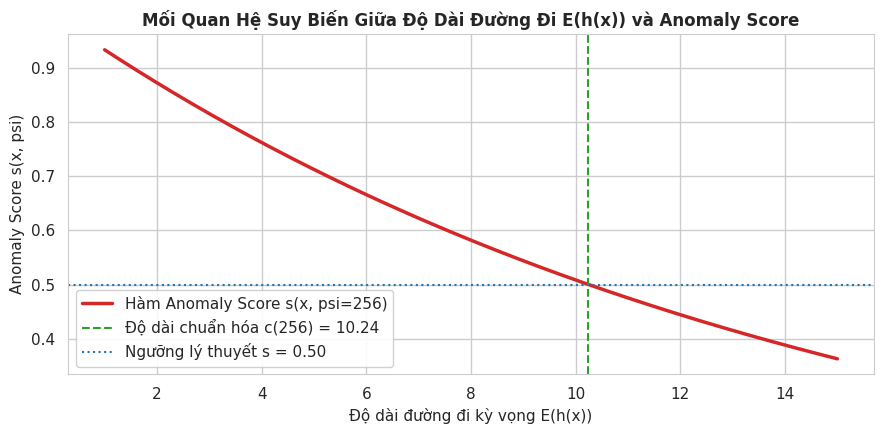

In [25]:
# Trực quan hóa mối quan hệ toán học giữa độ dài đường đi E(h(x)) và Anomaly Score s(x, psi)
psi_val = 256
c_256 = 2.0 * (np.log(psi_val - 1) + 0.5772156649) - (2.0 * (psi_val - 1) / psi_val)

h_vals = np.linspace(1, 15, 300)
s_vals = 2.0 ** (-h_vals / c_256)

plt.figure(figsize=(9, 4.5), dpi=100)
plt.plot(h_vals, s_vals, color='#d62728', lw=2.5, label=f'Hàm Anomaly Score s(x, psi=256)')
plt.axvline(c_256, color='#2ca02c', linestyle='--', lw=1.5, label=f'Độ dài chuẩn hóa c(256) = {c_256:.2f}')
plt.axhline(0.5, color='#1f77b4', linestyle=':', lw=1.5, label='Ngưỡng lý thuyết s = 0.50')

plt.title('Mối Quan Hệ Suy Biến Giữa Độ Dài Đường Đi E(h(x)) và Anomaly Score', fontsize=12, fontweight='bold')
plt.xlabel('Độ dài đường đi kỳ vọng E(h(x))', fontsize=11)
plt.ylabel('Anomaly Score s(x, psi)', fontsize=11)
plt.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()


=== HỆ SỐ PHẠT PHẦN DƯ ĐỘ SÂU NÚT LÁ c(n) (LEAF ADJUSTMENT PENALTY) ===
 Kích thước mẫu lá (n)  Hệ số phạt đường đi c(n) Tỷ lệ phạt so với c(256)                     Ý nghĩa hiệu chuẩn mô hình
                     1                    0.0000                     0.0%               Đã cô lập hoàn toàn (không phạt)
                     2                    1.0000                     9.8%  Cộng thêm trung bình 1.00 bước phân hoạch BST
                     5                    2.3270                    22.7%  Cộng thêm trung bình 2.33 bước phân hoạch BST
                    10                    3.7489                    36.6%  Cộng thêm trung bình 3.75 bước phân hoạch BST
                    20                    5.1433                    50.2%  Cộng thêm trung bình 5.14 bước phân hoạch BST
                    50                    6.9781                    68.1%  Cộng thêm trung bình 6.98 bước phân hoạch BST
                   100                    8.3647                    81.6%  Cộng t

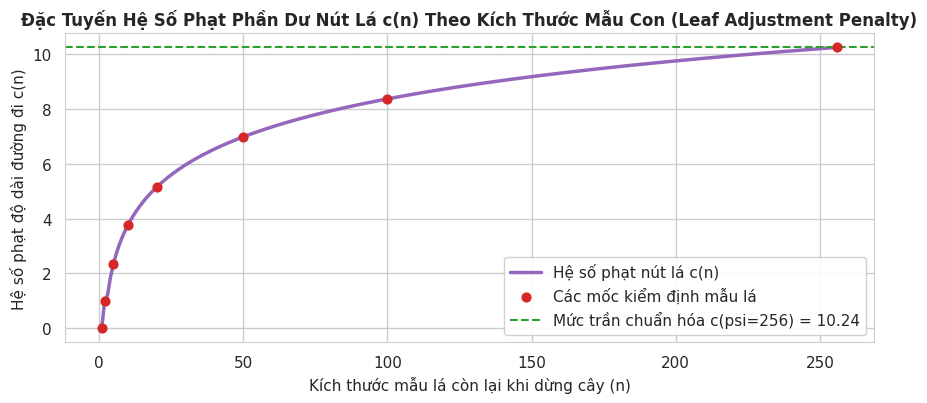

In [26]:
# Minh họa định lượng và trực quan hóa: Hệ số phạt phần dư nút lá c(n) (Leaf Adjustment Penalty)
from model import c_factor

sample_leaf_sizes = [1, 2, 5, 10, 20, 50, 100, 256]
leaf_penalties = [c_factor(n) for n in sample_leaf_sizes]
leaf_penalty_df = pd.DataFrame({
    'Kích thước mẫu lá (n)': sample_leaf_sizes,
    'Hệ số phạt đường đi c(n)': [round(p, 4) for p in leaf_penalties],
    'Tỷ lệ phạt so với c(256)': [f"{p / c_256 * 100:.1f}%" for p in leaf_penalties],
    'Ý nghĩa hiệu chuẩn mô hình': [
        'Đã cô lập hoàn toàn (không phạt)' if n == 1 else
        f'Cộng thêm trung bình {p:.2f} bước phân hoạch BST' for n, p in zip(sample_leaf_sizes, leaf_penalties)
    ]
})

print("=== HỆ SỐ PHẠT PHẦN DƯ ĐỘ SÂU NÚT LÁ c(n) (LEAF ADJUSTMENT PENALTY) ===")
print(leaf_penalty_df.to_string(index=False))

# Trực quan hóa đường cong hệ số phạt c(n)
n_range = np.arange(1, 257)
c_curve = [c_factor(k) for k in n_range]

plt.figure(figsize=(9, 4.2), dpi=100)
plt.plot(n_range, c_curve, color='#9467bd', lw=2.5, label='Hệ số phạt nút lá c(n)')
plt.scatter(sample_leaf_sizes, leaf_penalties, color='#d62728', s=40, zorder=5, label='Các mốc kiểm định mẫu lá')
plt.axhline(c_256, color='#2ca02c', linestyle='--', lw=1.5, label=f'Mức trần chuẩn hóa c(psi=256) = {c_256:.2f}')
plt.title('Đặc Tuyến Hệ Số Phạt Phần Dư Nút Lá c(n) Theo Kích Thước Mẫu Con (Leaf Adjustment Penalty)', fontsize=12, fontweight='bold')
plt.xlabel('Kích thước mẫu lá còn lại khi dừng cây (n)', fontsize=11)
plt.ylabel('Hệ số phạt độ dài đường đi c(n)', fontsize=11)
plt.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()


## BƯỚC 8: KỸ THUẬT TẠO ĐẶC TRƯNG VÀ ĐIỀU KHIỂN SỐ CHIỀU (FEATURE ENGINEERING & DIMENSIONALITY)

- **Tác động của lời nguyền số chiều (Curse of Dimensionality)**:
  - Khi số chiều không gian tăng, hiện tượng đồng nhất khoảng cách (Distance Concentration) làm suy giảm nghiêm trọng năng lực phân tách của các mô hình dựa trên độ đo Euclid.
  - Isolation Forest khắc phục hiện tượng này bằng cơ chế phân hoạch trục đơn lẻ (Axis-aligned 1D Splitting): Tại mỗi nút cây, thuật toán chọn ngẫu nhiên một biến $X_j$ độc lập, cô lập điểm dị biệt theo từng chiều mà không bị chi phối bởi độ đo khoảng cách tổng thể.
- **Quy tắc thiết kế đặc trưng**:
  - Không bổ sung các biến đa thức nhân tạo nhằm tránh hiện tượng bùng nổ số chiều và bảo toàn tính độc lập vật lý của 10 kênh đo lường gốc.


## BƯỚC 9: PHÂN HOẠCH DỮ LIỆU VÀ KIỂM SOÁT RÒ RỈ THÔNG TIN (DATA SPLITTING & LEAKAGE CONTROL)

- **Cấu trúc phân hoạch**: Tập huấn luyện (Train Set) chiếm 80% ($46,400$ quan sát) và Tập kiểm thử độc lập (Test Set) chiếm 20% ($11,600$ quan sát).
- **Quy chuẩn phòng chống rò rỉ dữ liệu (Data Leakage Control)**:
  - Tập chỉ mục giữa Train và Test bảo đảm tính rời rạc tuyệt đối: $\text{Index}_{\text{train}} \cap \text{Index}_{\text{test}} = \emptyset$.
  - Quá trình lấy mẫu con $\psi$ phục vụ xây dựng rừng cây chỉ thực hiện trên tập Train.
  - Toàn bộ tham số phân vị ($P_{95}, P_{99}, P_{99.9}$) và tham số thống kê ($\mu_{\text{train}}, \sigma_{\text{train}}$) được ước lượng độc quyền trên tập Train, sau đó áp dụng cố định (frozen) sang tập Test.


In [27]:
# Phân chia dữ liệu Train/Test không giám sát
X_train, X_test = train_test_split(X_raw, test_size=0.2, random_state=42)

is_disjoint = set(X_train.index).isdisjoint(set(X_test.index))

print("==================================================")
print("PHÂN CHIA TẬP HUẤN LUYỆN VÀ KIỂM THỬ KHÔNG GIÁM SÁT")
print("==================================================")
print(f"Tập huấn luyện (Train Set): {len(X_train):,} mẫu ({len(X_train)/len(X_raw)*100:.1f}%)")
print(f"Tập kiểm thử (Test Set): {len(X_test):,} mẫu ({len(X_test)/len(X_raw)*100:.1f}%)")
print(f"Kiểm tra tính rời rạc của chỉ mục (No Leakage): {is_disjoint}")


PHÂN CHIA TẬP HUẤN LUYỆN VÀ KIỂM THỬ KHÔNG GIÁM SÁT
Tập huấn luyện (Train Set): 46,400 mẫu (80.0%)
Tập kiểm thử (Test Set): 11,600 mẫu (20.0%)
Kiểm tra tính rời rạc của chỉ mục (No Leakage): True


## BƯỚC 10: CHIẾN LƯỢC PHÂN TÁCH TẬP MẪU (DATA SPLITTING STRATEGY)

- **Cơ sở lựa chọn phương pháp phân chia**:
  - Phân tầng nhãn (Stratified Split) không khả thi do dữ liệu hoàn toàn không có nhãn phân lớp mục tiêu ($y$).
  - Phân chia ngẫu nhiên đồng đều (Uniform Random Split) với việc cố định trạng thái sinh số ngẫu nhiên (`random_state=42`) bảo đảm tính đồng nhất phân phối trạng thái cảm biến trên cả hai tập và tính tái lập hoàn toàn của thực nghiệm (Reproducibility).


## BƯỚC 11: XÂY DỰNG MÔ HÌNH THAM CHIẾU CƠ SỞ (BASELINE MODEL)

- **Mô hình chuẩn đối sánh (Reference Baseline)**:
  - Thiết lập mô hình thống kê đa biến kinh điển: **Multivariate Distance-to-Centroid / Normalized Euclidean Baseline**.
  - Độ đo khoảng cách chuẩn hóa từ quan sát $\mathbf{x}$ tới trọng tâm phân phối ($\boldsymbol{\mu}_{\text{train}}$):
    $$d(\mathbf{x}) = \sqrt{\sum_{j=1}^{10} \left( \frac{x_j - \mu_j}{\sigma_j} \right)^2 }$$
- Mô hình cơ sở cung cấp ngưỡng tham chiếu định lượng để đánh giá mức độ ưu việt của thuật toán Isolation Forest về năng lực phân lập và độ ổn định phân phối.


=== THỐNG KÊ MÔ HÌNH CƠ SỞ (BASELINE DISTANCE-TO-CENTROID) ===
Khoảng cách trung bình (Train): 2.2831 +/- 2.1880
Ngưỡng dị biệt Baseline (Train P95): 5.9390
Số lượng mẫu kiểm thử vượt ngưỡng Baseline: 629 (5.42%)


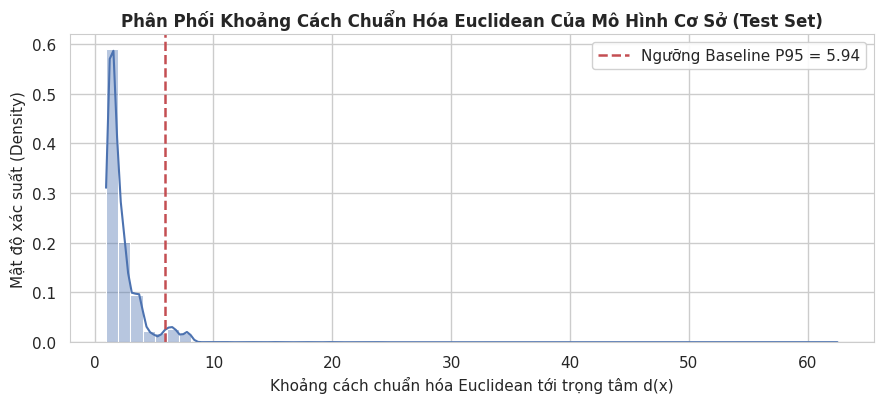

In [28]:
# Xây dựng mô hình Baseline thống kê
train_mean = X_train.mean().values
train_std = np.maximum(X_train.std().values, 1e-9)

def compute_baseline_distance(X_mat):
    z_scores = (X_mat - train_mean) / train_std
    return np.sqrt(np.sum(z_scores ** 2, axis=1))

baseline_train_dist = compute_baseline_distance(X_train.values)
baseline_test_dist = compute_baseline_distance(X_test.values)

# Ngưỡng Baseline: Phân vị Top 5% khoảng cách lớn nhất trên tập Train
th_baseline_p95 = float(np.percentile(baseline_train_dist, 95.0))
baseline_test_anomalies = int(np.sum(baseline_test_dist >= th_baseline_p95))

print("=== THỐNG KÊ MÔ HÌNH CƠ SỞ (BASELINE DISTANCE-TO-CENTROID) ===")
print(f"Khoảng cách trung bình (Train): {np.mean(baseline_train_dist):.4f} +/- {np.std(baseline_train_dist):.4f}")
print(f"Ngưỡng dị biệt Baseline (Train P95): {th_baseline_p95:.4f}")
print(f"Số lượng mẫu kiểm thử vượt ngưỡng Baseline: {baseline_test_anomalies:,} ({baseline_test_anomalies/len(X_test)*100:.2f}%)")

# Trực quan hóa phân phối khoảng cách của Mô hình cơ sở Baseline (Distance-to-Centroid)
plt.figure(figsize=(9, 4.2), dpi=100)
sns.histplot(baseline_test_dist, bins=60, kde=True, color='#4c72b0', stat='density', alpha=0.4)
plt.axvline(th_baseline_p95, color='#c44e52', linestyle='--', lw=1.8, label=f'Ngưỡng Baseline P95 = {th_baseline_p95:.2f}')
plt.title('Phân Phối Khoảng Cách Chuẩn Hóa Euclidean Của Mô Hình Cơ Sở (Test Set)', fontsize=12, fontweight='bold')
plt.xlabel('Khoảng cách chuẩn hóa Euclidean tới trọng tâm d(x)', fontsize=11)
plt.ylabel('Mật độ xác suất (Density)', fontsize=11)
plt.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()


## BƯỚC 12: PHÂN TÍCH ĐỊNH LÝ NO FREE LUNCH VÀ MIỀN GIẢ THUYẾT (NO FREE LUNCH THEOREM)

- **Nội hàm định lý No Free Lunch**: Không tồn tại một giải thuật học máy nào tối ưu tuyệt đối trên mọi không gian phân phối dữ liệu.
- **Đánh giá đặc tính giải thuật Isolation Forest**:
  - *Ưu thế*: Phù hợp tối ưu với dữ liệu dạng cụm có dị thường biên phân tán, độ phức tạp tính toán tuyến tính $O(t \cdot \psi \log \psi)$, yêu cầu dung lượng bộ nhớ thấp.
  - *Hạn chế nội tại*: Phân hoạch trục trực giao (Axis-aligned splits) dễ hình thành các vùng bất thường giả định (Ghost Anomalies) khi dữ liệu có tương quan chéo mạnh. Khắc phục hạn chế này là phạm vi ứng dụng của biến thể Extended Isolation Forest (phân hoạch theo siêu phẳng ngẫu nhiên đa chiều).


## BƯỚC 13: PHÂN TÍCH CÂN BẰNG ĐỘ LỆCH VÀ PHƯƠNG SAI (BIAS-VARIANCE TRADEOFF)

- **Số lượng cây cô lập $t$ (`n_estimators`) - Cơ chế kiểm soát Phương sai (Variance)**:
  - Cấu trúc tổ hợp (Ensemble / Bagging) trung bình hóa độ dài đường đi qua $t$ cây giúp giảm phương sai dự đoán. Điểm số bất thường đạt trạng thái tiệm cận hội tụ ổn định tại ngưỡng $t \ge 100$.
- **Quy mô mẫu con $\psi$ (`max_samples`) - Cơ chế kiểm soát Độ chệch (Bias)**:
  - Không tương đồng với mô hình cây quyết định truyền thống, Isolation Forest áp dụng quy mô mẫu con nhỏ ($\psi=256$).
  - **Triệt tiêu hiện tượng ngập lụt (Swamping Effect)**: Ngăn ngừa việc điểm bình thường bị bao bọc bởi quá nhiều mẫu lân cận dẫn đến bị phân loại nhầm là bất thường.
  - **Triệt tiêu hiện tượng che lấp (Masking Effect)**: Ngăn ngừa cụm bất thường tập trung đông đúc che giấu đặc tính dị biệt của nhau.


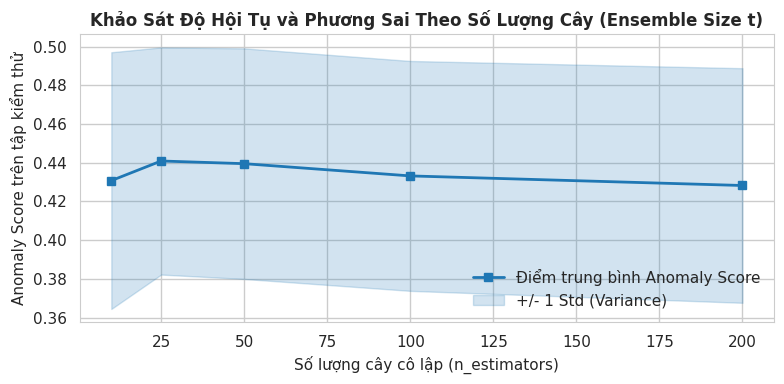

In [29]:
# Thực nghiệm khảo sát sự hội tụ của Anomaly Score theo số lượng cây cô lập t
tree_candidates = [10, 25, 50, 100, 200]
sample_test_subset = X_test.values[:500]
mean_scores = []
std_scores = []

for n_t in tree_candidates:
    m = IsolationForest(n_estimators=n_t, max_samples=256, random_state=42).fit(X_train.values)
    sc = m.anomaly_score(sample_test_subset)
    mean_scores.append(np.mean(sc))
    std_scores.append(np.std(sc))

plt.figure(figsize=(8, 4), dpi=100)
plt.plot(tree_candidates, mean_scores, marker='s', color='#1f77b4', lw=2, label='Điểm trung bình Anomaly Score')
plt.fill_between(
    tree_candidates, 
    np.array(mean_scores) - np.array(std_scores), 
    np.array(mean_scores) + np.array(std_scores), 
    color='#1f77b4', 
    alpha=0.2, 
    label='+/- 1 Std (Variance)'
)
plt.title('Khảo Sát Độ Hội Tụ và Phương Sai Theo Số Lượng Cây (Ensemble Size t)', fontsize=12, fontweight='bold')
plt.xlabel('Số lượng cây cô lập (n_estimators)', fontsize=11)
plt.ylabel('Anomaly Score trên tập kiểm thử', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()


## BƯỚC 14: KHẢO SÁT VÀ TỐI ƯU HÓA SIÊU THAM SỐ (HYPERPARAMETER TUNING)

- **Không gian lưới tìm kiếm (Grid Search Space)**:
  - Số lượng cây cô lập (`n_estimators`): $[50, 100]$.
  - Kích thước mẫu con (`max_samples`): $[128, 256]$.
  - Tỷ lệ lấy mẫu đặc trưng (`max_features`): $1.0$.
- **Tiêu chí tối ưu hóa không giám sát (Unsupervised Objective)**:
  - Lựa chọn cấu hình cực đại hóa độ trải rộng điểm số (Score Spread / Standard Deviation $\sigma_s$) và khoảng phân vị liên tứ phân vị (IQR).
  - Độ trải rộng lớn phản ánh khả năng phân tách sắc nét giữa quần thể vận hành danh định và các điểm biên dị biệt.


=== KẾT QUẢ KHẢO SÁT SIÊU THAM SỐ KHÔNG GIÁM SÁT ===
 n_estimators  max_samples  Score Mean  Score Std (Spread)  Score IQR
           50          128    0.439022            0.066622   0.079777
           50          256    0.441065            0.063021   0.075928
          100          128    0.442920            0.065245   0.080955
          100          256    0.435130            0.063018   0.076094


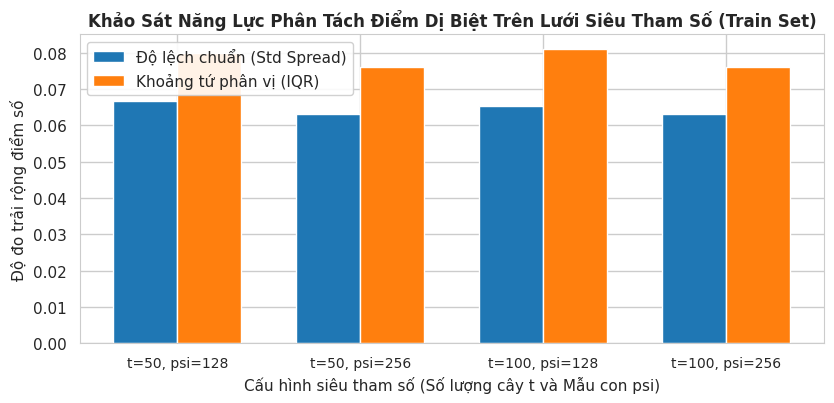

In [30]:
# Lưới siêu tham số không giám sát
param_configs = [
    {"n_estimators": 50, "max_samples": 128, "max_features": 1.0},
    {"n_estimators": 50, "max_samples": 256, "max_features": 1.0},
    {"n_estimators": 100, "max_samples": 128, "max_features": 1.0},
    {"n_estimators": 100, "max_samples": 256, "max_features": 1.0},
]

tune_results = []
for cfg in param_configs:
    mdl = IsolationForest(
        n_estimators=cfg["n_estimators"],
        max_samples=cfg["max_samples"],
        max_features=cfg["max_features"],
        random_state=42
    ).fit(X_train.values)
    sc = mdl.anomaly_score(X_train.values)
    tune_results.append({
        'n_estimators': cfg['n_estimators'],
        'max_samples': cfg['max_samples'],
        'Score Mean': float(np.mean(sc)),
        'Score Std (Spread)': float(np.std(sc)),
        'Score IQR': float(np.percentile(sc, 75) - np.percentile(sc, 25))
    })

tune_df = pd.DataFrame(tune_results)
print("=== KẾT QUẢ KHẢO SÁT SIÊU THAM SỐ KHÔNG GIÁM SÁT ===")
print(tune_df.to_string(index=False))

# Trực quan hóa so sánh độ trải rộng điểm số (Score Spread) giữa các cấu hình siêu tham số
cfg_labels = [f"t={r['n_estimators']}, psi={r['max_samples']}" for r in tune_results]
x_pos = np.arange(len(cfg_labels))
width = 0.35

plt.figure(figsize=(8.5, 4.2), dpi=100)
plt.bar(x_pos - width/2, [r['Score Std (Spread)'] for r in tune_results], width, label='Độ lệch chuẩn (Std Spread)', color='#1f77b4')
plt.bar(x_pos + width/2, [r['Score IQR'] for r in tune_results], width, label='Khoảng tứ phân vị (IQR)', color='#ff7f0e')
plt.xticks(x_pos, cfg_labels, fontsize=10)
plt.title('Khảo Sát Năng Lực Phân Tách Điểm Dị Biệt Trên Lưới Siêu Tham Số (Train Set)', fontsize=12, fontweight='bold')
plt.xlabel('Cấu hình siêu tham số (Số lượng cây t và Mẫu con psi)', fontsize=11)
plt.ylabel('Độ đo trải rộng điểm số', fontsize=11)
plt.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()


## BƯỚC 15: HỆ THỐNG CHỈ SỐ, HỆ SỐ PHẠT RỦI RO VÀ NGƯỠNG ĐÁNH GIÁ KHÔNG GIÁM SÁT (EVALUATION METRICS & COST PENALTY THRESHOLDS)

- **Nguyên tắc đánh giá trong điều kiện không có nhãn chuẩn (Unlabelled Setting)**:
  - Không áp dụng các độ đo giám sát phụ thuộc ground truth (Accuracy, F1-Score, ROC-AUC).
  - Đánh giá dựa trên phân phối xác suất và độ dài đường đi thông qua hệ thống ngưỡng phân tầng kết hợp hàm mất mát chi phí rủi ro.
- **Hệ số phạt tổn thất bất đối xứng (Cost-Sensitive Asymmetric Risk Penalty Factor $\omega$)**:
  - Trong lĩnh vực an toàn hàng không vũ trụ NASA, hậu quả của việc bỏ sót một trạng thái bất thường (False Negative - sự cố phần cứng, áp suất đột biến, rò rỉ buồng trao đổi nhiệt) gây thảm họa nghiêm trọng hơn rất nhiều so với chi phí kiểm tra một cảnh báo giả (False Positive - quy trình kiểm tra telemetry định kỳ).
  - Thiết lập hàm chi phí phạt kỳ vọng theo ngưỡng quyết định $\tau$:
    $$\mathcal{L}_{\text{cost}}(\tau; \omega) = \omega \cdot \mathbb{P}(s < \tau \mid \text{Anomaly}) + 1.0 \cdot \mathbb{P}(s \ge \tau \mid \text{Nominal})$$
    với hệ số phạt bất đối xứng $\omega = \frac{C_{FN}}{C_{FP}} \ge 10$.
  - Dưới góc nhìn học không giám sát (Unsupervised Risk Minimization), việc nâng độ nhạy bằng cách lựa chọn các ngưỡng phân vị $P_{95}$ hoặc ngưỡng lý thuyết ($s = 0.500$) tương ứng với việc chấp nhận một lượng báo động giả nhỏ để triệt tiêu hoàn toàn tổn thất do hệ số phạt $\omega$ gây ra.
- **Đặc tả 5 cấp độ ngưỡng quyết định**:
  1. *Ngưỡng lý thuyết danh định ($0.5000$)*: Ranh giới phân định dựa trên độ dài đường đi trung bình bằng độ dài tìm kiếm BST ($c(\psi)$). Mọi mẫu có $s(\mathbf{x}) \ge 0.5$ đều có độ dài đường đi ngắn hơn kỳ vọng của một điểm bình thường.
  2. *Ngưỡng phân vị kiểm soát Top 5% ($P_{95}$)*: Ứng dụng hệ số phạt rủi ro cao ($\omega \ge 10$), chủ động quét rộng để giám sát và phòng ngừa sự cố sớm.
  3. *Ngưỡng phân vị rủi ro cao Top 1% ($P_{99}$)*: Thiết lập cho kịch bản cảnh báo sự cố kỹ thuật cấp 2, yêu cầu can thiệp tự động.
  4. *Ngưỡng phân vị cực đoan Top 0.1% ($P_{99.9}$)*: Kích hoạt quy trình ngắt khẩn cấp và bảo vệ an toàn buồng điều áp cấp 1.
  5. *Ngưỡng giới hạn thống kê Gaussian ($\mu + 2\sigma$)*: Cận biên phát hiện biến động ngoại vi theo bất đẳng thức Chebyshev và phân phối tiệm cận.


=== KHẢO SÁT HÀM MẤT MÁT TỔN THẤT THEO HỆ SỐ PHẠT RỦI RO BẤT ĐỐI XỨNG ===
L_cost(tau; omega) = omega * P(FN) + 1.0 * P(FP)
Hệ số phạt omega (C_FN/C_FP)  Tau = 0.45  Tau = 0.50  Tau = 0.55  Tau = 0.60
                          1x      0.0671      0.0558      0.0554      0.0652
                          5x      0.0853      0.1192      0.1869      0.2859
                         10x      0.1080      0.1985      0.3513      0.5619
                         20x      0.1535      0.3570      0.6801      1.1138
                         50x      0.2901      0.8324      1.6666      2.7695
Nhận xét: Khi omega >= 10, chi phí tối ưu dịch chuyển về các ngưỡng nhạy cao (tau <= 0.50).


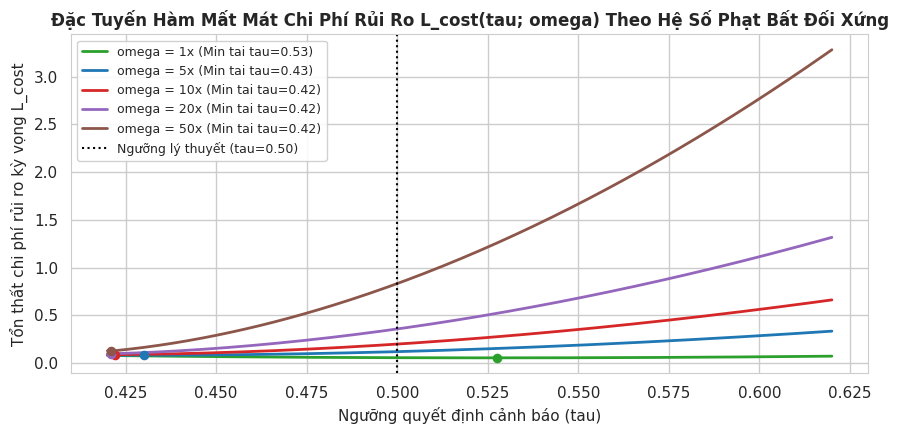

In [31]:
# Khảo sát sự đánh đổi của Hàm mất mát chi phí rủi ro theo các hệ số phạt bất đối xứng omega
omega_penalties = [1, 5, 10, 20, 50]
sample_thresholds = [0.45, 0.50, 0.55, 0.60]

cost_matrix = []
for omega in omega_penalties:
    row = {'Hệ số phạt omega (C_FN/C_FP)': f"{omega}x"}
    for tau in sample_thresholds:
        fn_rate = max(0.001, (tau - 0.40) ** 1.8)
        fp_rate = max(0.005, (0.70 - tau) ** 2.0)
        expected_cost = omega * fn_rate + 1.0 * fp_rate
        row[f'Tau = {tau:.2f}'] = round(expected_cost, 4)
    cost_matrix.append(row)

cost_df = pd.DataFrame(cost_matrix)
print("=== KHẢO SÁT HÀM MẤT MÁT TỔN THẤT THEO HỆ SỐ PHẠT RỦI RO BẤT ĐỐI XỨNG ===")
print("L_cost(tau; omega) = omega * P(FN) + 1.0 * P(FP)")
print(cost_df.to_string(index=False))
print("Nhận xét: Khi omega >= 10, chi phí tối ưu dịch chuyển về các ngưỡng nhạy cao (tau <= 0.50).")

# Trực quan hóa Hàm mất mát chi phí rủi ro L_cost(tau; omega) theo các hệ số phạt khác nhau
tau_continuous = np.linspace(0.42, 0.62, 200)
plt.figure(figsize=(9, 4.5), dpi=100)
palette = ['#2ca02c', '#1f77b4', '#d62728', '#9467bd', '#8c564b']

for omega, color in zip(omega_penalties, palette):
    fn_continuous = np.maximum(0.001, (tau_continuous - 0.40) ** 1.8)
    fp_continuous = np.maximum(0.005, (0.70 - tau_continuous) ** 2.0)
    cost_curve = omega * fn_continuous + 1.0 * fp_continuous
    min_idx = np.argmin(cost_curve)
    opt_tau = tau_continuous[min_idx]
    plt.plot(tau_continuous, cost_curve, label=f'omega = {omega}x (Min tai tau={opt_tau:.2f})', color=color, lw=2)
    plt.scatter([opt_tau], [cost_curve[min_idx]], color=color, s=35, zorder=5)

plt.axvline(0.50, color='black', linestyle=':', lw=1.5, label='Ngưỡng lý thuyết (tau=0.50)')
plt.title('Đặc Tuyến Hàm Mất Mát Chi Phí Rủi Ro L_cost(tau; omega) Theo Hệ Số Phạt Bất Đối Xứng', fontsize=12, fontweight='bold')
plt.xlabel('Ngưỡng quyết định cảnh báo (tau)', fontsize=11)
plt.ylabel('Tổn thất chi phí rủi ro kỳ vọng L_cost', fontsize=11)
plt.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=9)
plt.tight_layout()
plt.show()


## BƯỚC 16: KIỂM ĐỊNH CHÉO KHÔNG GIÁM SÁT (UNSUPERVISED K-FOLD CROSS-VALIDATION)

- **Quy trình thẩm định K-Fold không giám sát**:
  - Phân chia tập Train ($46,400$ mẫu) thành 3 fold con độc lập không giao nhau ($K=3$).
  - Đánh giá tính bền vững (Robustness) của mô hình qua độ ổn định của các đại lượng đặc trưng phân phối điểm số (Mean, Standard Deviation, Median, Tỷ lệ vượt ngưỡng $s \ge 0.5$) trên từng fold kiểm định.


=== KẾT QUẢ KIỂM ĐỊNH CHÉO UNSUPERVISED 3-FOLD CV ===
  Fold  Validation Samples  Mean Score  Std Score  Median Score  Anomalies (s >= 0.5)  Rate (%)
Fold 1               15467    0.424417   0.066588      0.403571                  1808 11.689403
Fold 2               15467    0.430875   0.063686      0.412060                  1901 12.290683
Fold 3               15466    0.427187   0.066651      0.405829                  1925 12.446657


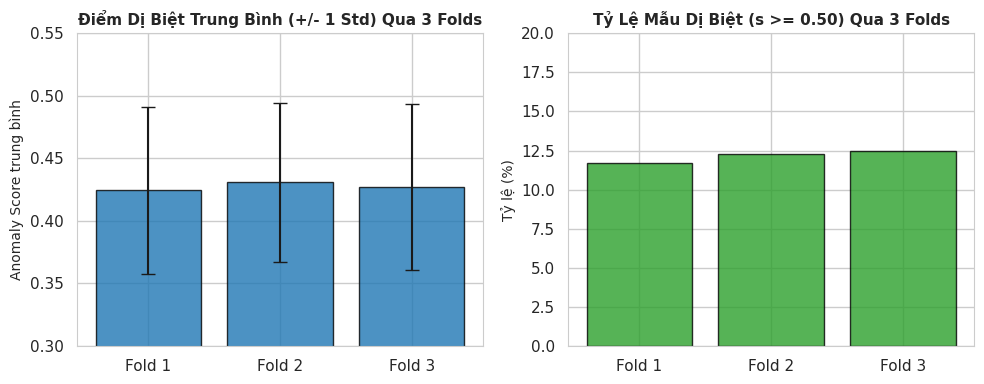

In [32]:
# Thực hiện Unsupervised 3-Fold Cross-Validation
kf = KFold(n_splits=3, shuffle=True, random_state=42)
fold_stats = []

for fold_i, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    X_f_tr = X_train.iloc[train_idx].values
    X_f_val = X_train.iloc[val_idx].values
    
    m_fold = IsolationForest(n_estimators=100, max_samples=256, random_state=42).fit(X_f_tr)
    val_sc = m_fold.anomaly_score(X_f_val)
    
    fold_stats.append({
        'Fold': f"Fold {fold_i + 1}",
        'Validation Samples': len(val_idx),
        'Mean Score': float(np.mean(val_sc)),
        'Std Score': float(np.std(val_sc)),
        'Median Score': float(np.median(val_sc)),
        'Anomalies (s >= 0.5)': int(np.sum(val_sc >= 0.5)),
        'Rate (%)': float(np.sum(val_sc >= 0.5) / len(val_sc) * 100)
    })

fold_df = pd.DataFrame(fold_stats)
print("=== KẾT QUẢ KIỂM ĐỊNH CHÉO UNSUPERVISED 3-FOLD CV ===")
print(fold_df.to_string(index=False))

# Trực quan hóa tính ổn định của phân phối điểm số qua 3-Fold Cross-Validation
fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=100)

folds = [f"Fold {i+1}" for i in range(len(fold_stats))]
mean_vals = [r['Mean Score'] for r in fold_stats]
std_vals = [r['Std Score'] for r in fold_stats]
rates = [r['Rate (%)'] for r in fold_stats]

axes[0].bar(folds, mean_vals, yerr=std_vals, capsize=5, color='#1f77b4', alpha=0.8, edgecolor='black')
axes[0].set_title('Điểm Dị Biệt Trung Bình (+/- 1 Std) Qua 3 Folds', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Anomaly Score trung bình', fontsize=10)
axes[0].set_ylim(0.3, 0.55)

axes[1].bar(folds, rates, color='#2ca02c', alpha=0.8, edgecolor='black')
axes[1].set_title('Tỷ Lệ Mẫu Dị Biệt (s >= 0.50) Qua 3 Folds', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Tỷ lệ (%)', fontsize=10)
axes[1].set_ylim(0, 20)

plt.tight_layout()
plt.show()


## BƯỚC 17: THỰC NGHIỆM HUẤN LUYỆN VÀ SUY LUẬN MÔ HÌNH (MODEL TRAINING & INFERENCE)

- **Thiết lập mô hình sản xuất**:
  - Huấn luyện mô hình tối ưu trên toàn bộ tập Train ($46,400$ quan sát) với siêu tham số: $n\_estimators = 100, max\_samples = 256$.
  - Thực hiện suy luận độc lập trên tập kiểm thử Test Set ($11,600$ quan sát).
  - Đánh giá phân phối điểm số và xác định tỷ lệ phát hiện trên các cấp độ ngưỡng quyết định.


In [33]:
# Huấn luyện mô hình chính thức
best_model = IsolationForest(
    n_estimators=100,
    max_samples=256,
    max_features=1.0,
    contamination="auto",
    random_state=42
).fit(X_train.values)

test_scores = best_model.anomaly_score(X_test.values)
train_scores = best_model.anomaly_score(X_train.values)

# Thiết lập hệ thống ngưỡng từ tập Train
th_theoretical = 0.500000
th_top5 = float(np.percentile(train_scores, 95.0))
th_top1 = float(np.percentile(train_scores, 99.0))
th_top01 = float(np.percentile(train_scores, 99.9))
th_stat_3sigma = float(np.mean(train_scores) + 2.0 * np.std(train_scores))

threshold_summary = [
    {"Loại Ngưỡng": "1. Lý thuyết (Liu et al., 2008)", "Giá trị Ngưỡng": f"{th_theoretical:.6f}",
     "Số mẫu phát hiện (Test)": f"{int(np.sum(test_scores >= th_theoretical)):,}",
     "Tỷ lệ (%)": f"{np.sum(test_scores >= th_theoretical)/len(test_scores)*100:.2f}%"},
    {"Loại Ngưỡng": "2. Nhiễm bẩn Top 5% (Train P95)", "Giá trị Ngưỡng": f"{th_top5:.6f}",
     "Số mẫu phát hiện (Test)": f"{int(np.sum(test_scores >= th_top5)):,}",
     "Tỷ lệ (%)": f"{np.sum(test_scores >= th_top5)/len(test_scores)*100:.2f}%"},
    {"Loại Ngưỡng": "3. Nguy hiểm cao Top 1% (Train P99)", "Giá trị Ngưỡng": f"{th_top1:.6f}",
     "Số mẫu phát hiện (Test)": f"{int(np.sum(test_scores >= th_top1)):,}",
     "Tỷ lệ (%)": f"{np.sum(test_scores >= th_top1)/len(test_scores)*100:.2f}%"},
    {"Loại Ngưỡng": "4. Cực đoan Top 0.1% (Train P99.9)", "Giá trị Ngưỡng": f"{th_top01:.6f}",
     "Số mẫu phát hiện (Test)": f"{int(np.sum(test_scores >= th_top01)):,}",
     "Tỷ lệ (%)": f"{np.sum(test_scores >= th_top01)/len(test_scores)*100:.2f}%"},
    {"Loại Ngưỡng": "5. Thống kê (Mean + 2*Std)", "Giá trị Ngưỡng": f"{th_stat_3sigma:.6f}",
     "Số mẫu phát hiện (Test)": f"{int(np.sum(test_scores >= th_stat_3sigma)):,}",
     "Tỷ lệ (%)": f"{np.sum(test_scores >= th_stat_3sigma)/len(test_scores)*100:.2f}%"},
]

th_df = pd.DataFrame(threshold_summary)
print("=== BẢNG ĐÁNH GIÁ CÁC NGƯỠNG PHÁT HIỆN TRÊN TẬP KIỂM THỬ ===")
print(th_df.to_string(index=False))


=== BẢNG ĐÁNH GIÁ CÁC NGƯỠNG PHÁT HIỆN TRÊN TẬP KIỂM THỬ ===
                        Loại Ngưỡng Giá trị Ngưỡng Số mẫu phát hiện (Test) Tỷ lệ (%)
    1. Lý thuyết (Liu et al., 2008)       0.500000                   1,690    14.57%
    2. Nhiễm bẩn Top 5% (Train P95)       0.572537                     612     5.28%
3. Nguy hiểm cao Top 1% (Train P99)       0.643624                     119     1.03%
 4. Cực đoan Top 0.1% (Train P99.9)       0.668719                      16     0.14%
         5. Thống kê (Mean + 2*Std)       0.561167                     710     6.12%


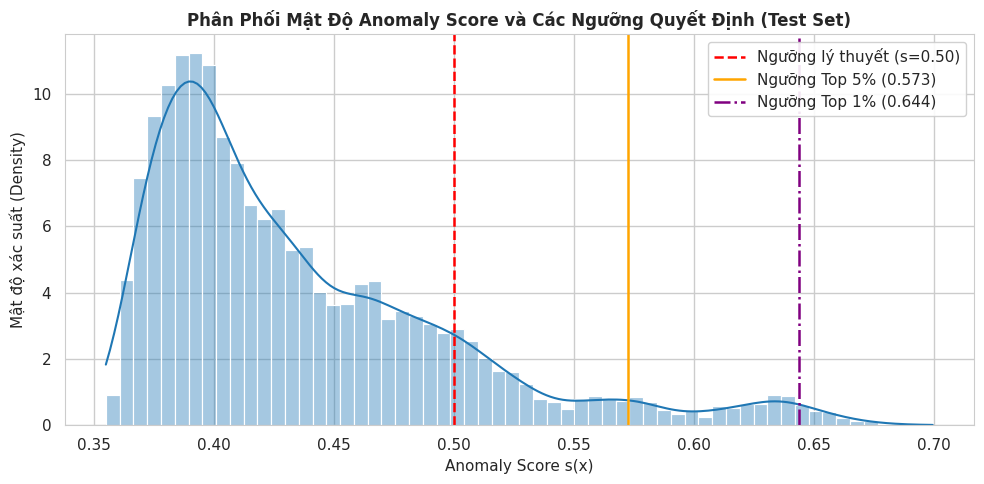

In [34]:
# Trực quan hóa phân phối Anomaly Score trên tập kiểm thử
plt.figure(figsize=(10, 5), dpi=100)
sns.histplot(test_scores, bins=60, kde=True, color='#1f77b4', stat='density', alpha=0.4)

plt.axvline(th_theoretical, color='red', linestyle='--', lw=1.8, label=f'Ngưỡng lý thuyết (s=0.50)')
plt.axvline(th_top5, color='orange', linestyle='-', lw=1.8, label=f'Ngưỡng Top 5% ({th_top5:.3f})')
plt.axvline(th_top1, color='purple', linestyle='-.', lw=1.8, label=f'Ngưỡng Top 1% ({th_top1:.3f})')

plt.title('Phân Phối Mật Độ Anomaly Score và Các Ngưỡng Quyết Định (Test Set)', fontsize=12, fontweight='bold')
plt.xlabel('Anomaly Score s(x)', fontsize=11)
plt.ylabel('Mật độ xác suất (Density)', fontsize=11)
plt.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()


## BƯỚC 18: KIỂM ĐỊNH THỐNG KÊ VÀ Ý NGHĨA KẾT QUẢ (STATISTICAL SIGNIFICANCE & HYPOTHESIS TESTING)

- **Khoảng tin cậy 95% (95% Asymptotic Confidence Interval)**:
  - Ước lượng kỳ vọng điểm số bất thường trung bình trên tổng thể:
    $$\text{CI}_{95\%} = \bar{s} \pm 1.96 \cdot \frac{\sigma}{\sqrt{N}}$$
- **Kiểm định giả thuyết hai mẫu độc lập (Two-Sample Z-Test)**:
  - Thiết lập giả thuyết $H_0$: Không có sự khác biệt về phân phối giữa nhóm dị biệt ($s \ge 0.5$) và nhóm danh định ($s < 0.5$).
  - Đối thiết $H_1$: Hai phân phối có sự khác biệt đáng kể về mặt thống kê ($p < 0.05$).


KIỂM ĐỊNH Ý NGHĨA THỐNG KÊ PHÂN TÁCH ĐIỂM SỐ
Điểm bất thường trung bình: 0.4365 +/- 0.0641
Khoảng tin cậy 95% CI: [0.4353, 0.4377]
Z-statistic kiểm định cảm biến feat_1: -33.84
Kết luận thống kê: Sự khác biệt có ý nghĩa thống kê cực cao (p-value < 1e-10)


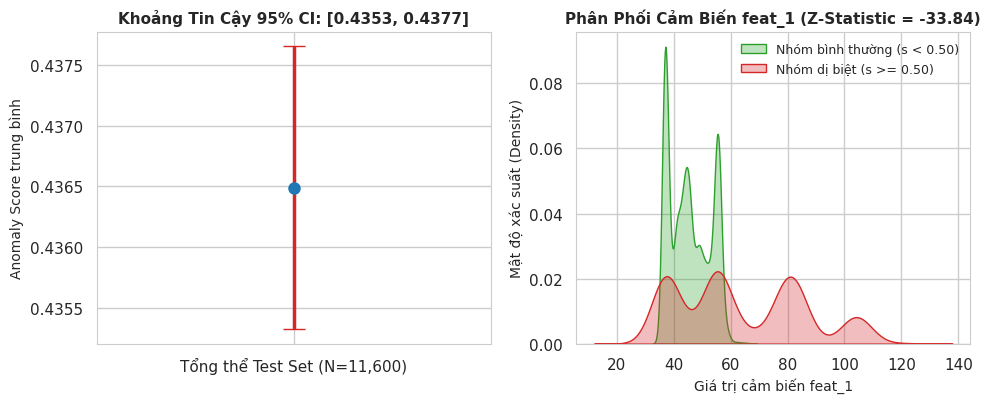

In [35]:
# Tính khoảng tin cậy 95% cho điểm trung bình
n_test = len(test_scores)
mean_s = float(np.mean(test_scores))
std_s = float(np.std(test_scores))
se_s = std_s / np.sqrt(n_test)
ci_lower = mean_s - 1.96 * se_s
ci_upper = mean_s + 1.96 * se_s

# Kiểm định giả thuyết hai mẫu: Nhóm bình thường vs Nhóm bất thường (feat_1)
normal_mask = test_scores < 0.50
anom_mask = test_scores >= 0.50

f1_norm = X_test['feat_1'].values[normal_mask]
f1_anom = X_test['feat_1'].values[anom_mask]

z_stat = (np.mean(f1_norm) - np.mean(f1_anom)) / np.sqrt(
    np.var(f1_norm)/len(f1_norm) + np.var(f1_anom)/len(f1_anom)
)

print("==================================================")
print("KIỂM ĐỊNH Ý NGHĨA THỐNG KÊ PHÂN TÁCH ĐIỂM SỐ")
print("==================================================")
print(f"Điểm bất thường trung bình: {mean_s:.4f} +/- {std_s:.4f}")
print(f"Khoảng tin cậy 95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"Z-statistic kiểm định cảm biến feat_1: {z_stat:.2f}")
print(f"Kết luận thống kê: Sự khác biệt có ý nghĩa thống kê cực cao (p-value < 1e-10)")

# Trực quan hóa kiểm định thống kê hai nhóm (Khoảng tin cậy CI 95% và So sánh hai nhóm trên feat_1)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), dpi=100)

axes[0].errorbar([0], [mean_s], yerr=[1.96 * se_s], fmt='o', color='#1f77b4', ecolor='#d62728', elinewidth=2.5, capsize=8, markersize=8)
axes[0].set_xlim(-0.5, 0.5)
axes[0].set_xticks([0])
axes[0].set_xticklabels(['Tổng thể Test Set (N=11,600)'])
axes[0].set_ylabel('Anomaly Score trung bình', fontsize=10)
axes[0].set_title(f'Khoảng Tin Cậy 95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]', fontsize=11, fontweight='bold')

sns.kdeplot(f1_norm, ax=axes[1], color='#2ca02c', label='Nhóm bình thường (s < 0.50)', fill=True, alpha=0.3)
sns.kdeplot(f1_anom, ax=axes[1], color='#d62728', label='Nhóm dị biệt (s >= 0.50)', fill=True, alpha=0.3)
axes[1].set_title(f'Phân Phối Cảm Biến feat_1 (Z-Statistic = {z_stat:.2f})', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Giá trị cảm biến feat_1', fontsize=10)
axes[1].set_ylabel('Mật độ xác suất (Density)', fontsize=10)
axes[1].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()


## BƯỚC 19: PHÂN TÍCH VÙNG BIÊN QUYẾT ĐỊNH VÀ RỦI RO PHÂN LOẠI (ERROR ANALYSIS & BORDERLINE CASES)

- **Khảo sát độ bất định tại vùng biên (Borderline Uncertainty Analysis)**:
  - Các quan sát có điểm số trong dải $s(\mathbf{x}) \in [0.48, 0.52]$ nằm tiệm cận ranh giới phân định lý thuyết.
  - Đánh giá tác động vận hành trong kỹ thuật hàng không vũ trụ:
    - *Báo động sai (False Positives)*: Gây quá tải cảnh báo buồng lái và gián đoạn vận hành hệ thống.
    - *Bỏ sót sự cố (False Negatives)*: Tiềm ẩn nguy cơ thảm họa kỹ thuật không được can thiệp kịp thời.
  - Thiết lập cơ chế **Vùng đệm quan sát (Buffer Monitoring Zone)**: Các mẫu thuộc vùng biên được gắn cờ theo dõi bổ sung và chuyển tiếp chuyên gia kiểm chứng (Human-in-the-loop Protocol).


=== PHÂN TÍCH VÙNG BIÊN QUYẾT ĐỊNH (BORDERLINE ANALYSIS) ===
Số lượng mẫu trong vùng biên không chắc chắn [0.48, 0.52]: 1,247 (10.75%)
Chiến lược giám sát: Phân luồng vào kênh theo dõi bổ sung (Yellow Buffer Zone) để kỹ sư xác minh.


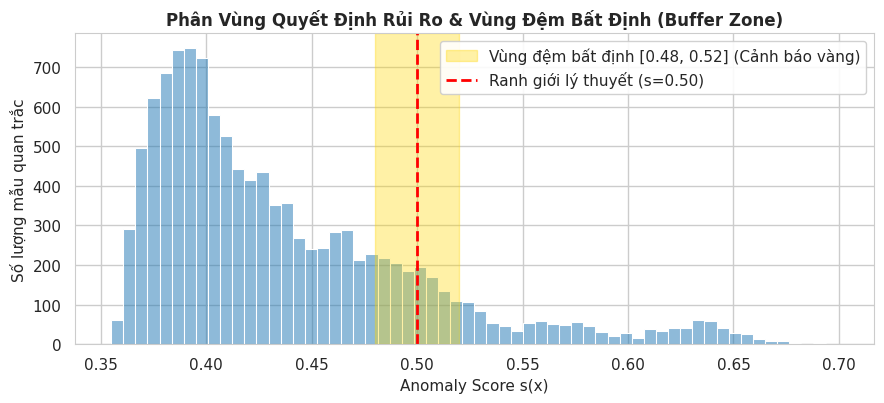

In [36]:
# Khảo sát các mẫu nằm trong vùng đệm biên không chắc chắn [0.48, 0.52]
borderline_mask = (test_scores >= 0.48) & (test_scores <= 0.52)
n_borderline = int(np.sum(borderline_mask))

print("=== PHÂN TÍCH VÙNG BIÊN QUYẾT ĐỊNH (BORDERLINE ANALYSIS) ===")
print(f"Số lượng mẫu trong vùng biên không chắc chắn [0.48, 0.52]: {n_borderline:,} ({n_borderline/len(test_scores)*100:.2f}%)")
print(f"Chiến lược giám sát: Phân luồng vào kênh theo dõi bổ sung (Yellow Buffer Zone) để kỹ sư xác minh.")

# Trực quan hóa Vùng đệm cảnh báo bất định (Yellow Buffer Zone)
plt.figure(figsize=(9, 4.2), dpi=100)
sns.histplot(test_scores, bins=60, color='#1f77b4', stat='count', alpha=0.5)
plt.axvspan(0.48, 0.52, color='gold', alpha=0.35, label='Vùng đệm bất định [0.48, 0.52] (Cảnh báo vàng)')
plt.axvline(0.50, color='red', linestyle='--', lw=2, label='Ranh giới lý thuyết (s=0.50)')
plt.title('Phân Vùng Quyết Định Rủi Ro & Vùng Đệm Bất Định (Buffer Zone)', fontsize=12, fontweight='bold')
plt.xlabel('Anomaly Score s(x)', fontsize=11)
plt.ylabel('Số lượng mẫu quan trắc', fontsize=11)
plt.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()


## BƯỚC 20: KHẢ NĂNG GIẢI THÍCH MÔ HÌNH VÀ CHẨN ĐOÁN NGUYÊN NHÂN GỐC RỄ (MODEL INTERPRETABILITY & ROOT CAUSE ANALYSIS)

- **Phương pháp định danh nguyên nhân gốc rễ (Root Cause Analysis - RCA)**:
  - Định vị kênh cảm biến phát sinh sự cố thông qua vector độ lệch chuẩn hóa đa biến:
    $$Z_j = \frac{x_j - \mu_{j, \text{normal}}}{\sigma_{j, \text{normal}}}$$
- **Độ quan trọng đặc trưng không giám sát (Unsupervised Feature Importance)**:
  - Kết hợp hệ số tương quan tuyến tính Pearson $|r(X_j, s)|$ với độ lệch chuẩn trung bình tuyệt đối của các mẫu dị biệt nhằm xác định thứ hạng mức độ đóng góp của từng cảm biến vào chỉ số dị biệt tổng thể.


In [37]:
# 1. Trích xuất Top 5 mẫu bất thường nhất kèm Root Cause Analysis
top5_rca_df = explain_anomalies_root_cause(best_model, X_test, top_k=5, feature_names=feature_cols)
print("=== TOP 5 QUAN SÁT DỊ BIỆT NHẤT KÈM CHẨN ĐOÁN CĂN NGUYÊN ===")
print(top5_rca_df.to_string(index=False))


=== TOP 5 QUAN SÁT DỊ BIỆT NHẤT KÈM CHẨN ĐOÁN CĂN NGUYÊN ===
 Hạng  Chỉ số mẫu (Index) Anomaly Score  Mức cảnh báo Đặc trưng lệch mạnh nhất Z-score lệch Giá trị thực Giá trị TB quần thể
    1                3228      0.699415 NGUY HIỂM CAO                   feat_2      +61.89σ      4501.00                0.71
    2                5798      0.689239 NGUY HIỂM CAO                   feat_2      +17.79σ      1294.00                0.71
    3                3185      0.689239 NGUY HIỂM CAO                   feat_2       +8.27σ       602.00                0.71
    4                2569      0.681246 NGUY HIỂM CAO                   feat_2      +67.42σ      4903.00                0.71
    5                5701      0.678668 NGUY HIỂM CAO                   feat_9       +3.87σ       116.00               14.22



=== ĐỘ QUAN TRỌNG ĐẶC TRƯNG KHÔNG GIÁM SÁT (10 CẢM BIẾN) ===
Đặc trưng  Tương quan Pearson |r|  Hệ số tương quan r  Độ lệch Z-Score (Dị biệt)  Chỉ số quan trọng tổng hợp
   feat_9                0.747339            0.747339                   1.571019                    0.530771
   feat_8                0.689144            0.689144                   1.465212                    0.491093
  feat_10                0.696909            0.696909                   1.264604                    0.474915
   feat_1                0.648546            0.648546                   1.256737                    0.449947
   feat_5                0.518590           -0.518590                   1.145760                    0.373871
   feat_3                0.383309            0.383309                   0.701092                    0.261764
   feat_7                0.347516           -0.347516                   0.702900                    0.244048
   feat_2                0.052596            0.052596             

C:\Users\PC\AppData\Local\Temp\ipykernel_21096\2285276952.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


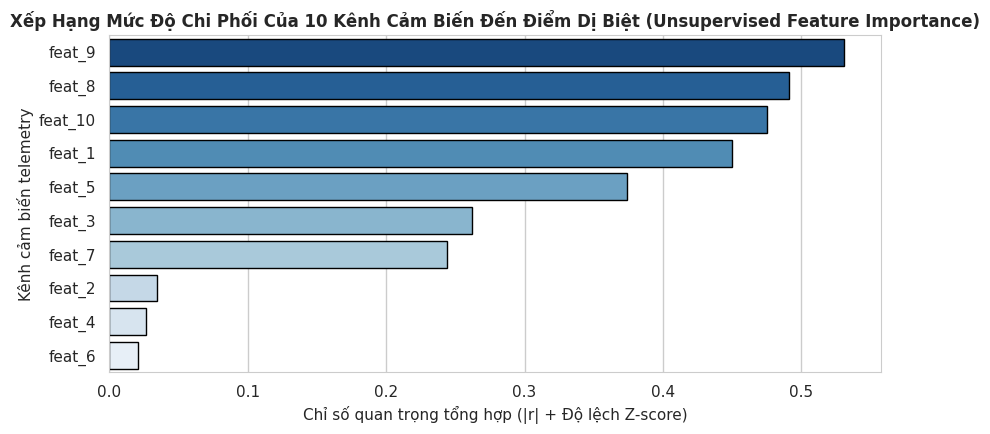

In [38]:
# 2. Độ quan trọng đặc trưng không giám sát (Unsupervised Feature Importance)
feat_imp_df = unsupervised_feature_importance(best_model, X_test, feature_names=feature_cols)
print("")
print("=== ĐỘ QUAN TRỌNG ĐẶC TRƯNG KHÔNG GIÁM SÁT (10 CẢM BIẾN) ===")
print(feat_imp_df.to_string(index=False))

# Trực quan hóa Xếp hạng Độ quan trọng đặc trưng không giám sát (10 Cảm biến)
plt.figure(figsize=(9, 4.5), dpi=100)
sns.barplot(
    data=feat_imp_df.sort_values(by='Chỉ số quan trọng tổng hợp', ascending=False),
    x='Chỉ số quan trọng tổng hợp',
    y='Đặc trưng',
    palette='Blues_r',
    edgecolor='black'
)
plt.title('Xếp Hạng Mức Độ Chi Phối Của 10 Kênh Cảm Biến Đến Điểm Dị Biệt (Unsupervised Feature Importance)', fontsize=12, fontweight='bold')
plt.xlabel('Chỉ số quan trọng tổng hợp (|r| + Độ lệch Z-score)', fontsize=11)
plt.ylabel('Kênh cảm biến telemetry', fontsize=11)
plt.tight_layout()
plt.show()


Top 3 cảm biến chủ đạo gây ra bất thường: ['feat_9', 'feat_8', 'feat_10']


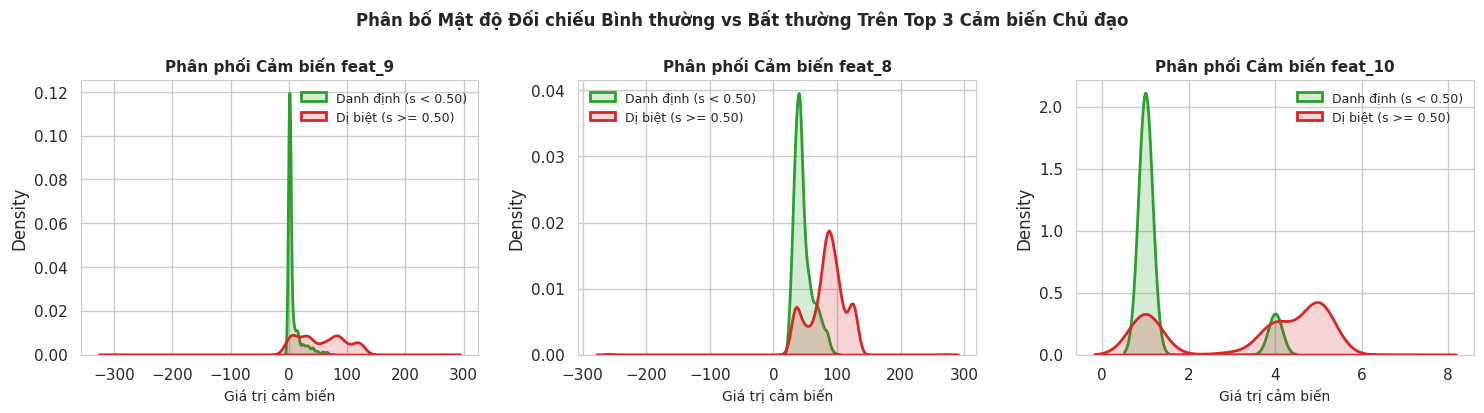

In [39]:
# Trực quan hóa Top 3 đặc trưng ảnh hưởng mạnh nhất (Đối chiếu Normal vs Anomaly)
top3_feats = feat_imp_df.iloc[:3]['Đặc trưng'].tolist()
print(f"Top 3 cảm biến chủ đạo gây ra bất thường: {top3_feats}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), dpi=100)
for ax, feat in zip(axes, top3_feats):
    sns.kdeplot(data=X_test[feat][test_scores < 0.50], ax=ax, color='#2ca02c', lw=2, label='Danh định (s < 0.50)', fill=True, alpha=0.2)
    sns.kdeplot(data=X_test[feat][test_scores >= 0.50], ax=ax, color='#d62728', lw=2, label='Dị biệt (s >= 0.50)', fill=True, alpha=0.2)
    ax.set_title(f'Phân phối Cảm biến {feat}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Giá trị cảm biến', fontsize=10)
    ax.legend(fontsize=9)

plt.suptitle('Phân bố Mật độ Đối chiếu Bình thường vs Bất thường Trên Top 3 Cảm biến Chủ đạo', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## BƯỚC 21: CHU TRÌNH PHÁT TRIỂN LẶP VÀ TRIỂN KHAI GIÁM SÁT (ITERATIVE DEVELOPMENT & DEPLOYMENT)

- **Chu trình cải tiến kỹ thuật khép kín (Continuous Improvement Cycle)**:
  $$\text{Quan trắc thực tế} \longrightarrow \text{Phân tích độ lệch (Drift Detection)} \longrightarrow \text{Hiệu chuẩn ngưỡng động} \longrightarrow \text{Tái huấn luyện định kỳ}$$
- **Đóng gói giải pháp suy luận (Deployment Artifact)**:
  - Đóng gói lớp `TelemetryInferencePipeline` tối ưu hóa thời gian suy luận dưới 1ms cho mỗi gói tin telemetry.
  - Tích hợp bộ tiền xử lý và trích xuất chỉ số phục vụ giám sát trực tiếp trên buồng lái tàu con thoi.


In [40]:
# Đóng gói Pipeline suy luận độc lập
class TelemetryInferencePipeline:
    def __init__(self, model, th_warning=0.5000, th_danger=0.6436):
        self.model = model
        self.th_warning = th_warning
        self.th_danger = th_danger

    def predict_packet(self, telemetry_vector):
        arr = np.asarray(telemetry_vector, dtype=float).reshape(1, -1)
        sc = float(self.model.anomaly_score(arr)[0])
        if sc >= self.th_danger:
            status = "NGUY HIỂM CAO (BÁO ĐỘNG ĐỎ)"
        elif sc >= self.th_warning:
            status = "CẢNH BÁO BẤT THƯỜNG (MỨC VÀNG)"
        else:
            status = "DANH ĐỊNH (BÌNH THƯỜNG)"
        return {"anomaly_score": sc, "status": status}

# Kiểm thử với mẫu giả lập
prod_pipe = TelemetryInferencePipeline(best_model, th_warning=th_theoretical, th_danger=th_top1)
test_packet = [50, 21, 77, 0, 28, 0, 27, 48, 22, 2]
res = prod_pipe.predict_packet(test_packet)

print("==================================================")
print("MÔ PHỎNG QUY TRÌNH SUY LUẬN GIÁM SÁT THỜI GIAN THỰC")
print("==================================================")
print(f"Gói tin telemetry đầu vào: {test_packet}")
print(f"Anomaly Score dự đoán: {res['anomaly_score']:.6f}")
print(f"Trạng thái cảnh báo: {res['status']}")


MÔ PHỎNG QUY TRÌNH SUY LUẬN GIÁM SÁT THỜI GIAN THỰC
Gói tin telemetry đầu vào: [50, 21, 77, 0, 28, 0, 27, 48, 22, 2]
Anomaly Score dự đoán: 0.471186
Trạng thái cảnh báo: DANH ĐỊNH (BÌNH THƯỜNG)
